# Ch9. ARIMA Models
**Forecasting: Principles & Practice (Python Edition)**  
Lab Notebook · [github.com/bcseong2/fpppy-labs](https://github.com/bcseong2/fpppy-labs)

In [1]:
%pip install statsforecast neuralforecast hierarchicalforecast mlforecast utilsforecast


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## [Slide 2] Differencing

In [2]:
from statsmodels.tsa.stattools import kpss

stat, p_value, lags, crit = kpss(y, regression="c", nlags=5)
print(f"p-value = {p_value:.4f}")
# p < 0.05: reject stationarity => differencing required

NameError: name 'y' is not defined

## [Slide 4] Automated Differencing

In [3]:
from statsforecast.arima import ndiffs, nsdiffs

# Number of first differences (uses sequence of KPSS tests)
d  = ndiffs(y, alpha=0.05, test="kpss", max_d=2)

# Number of seasonal differences
# (uses seasonal strength measure; recommends D=1 if Fs >= 0.64)
D  = nsdiffs(y, m=12, test="seas", max_D=1)

print(f"d = {d}, D = {D}")

/Data2/data/jc25/forecast/fpppy-labs/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'y' is not defined

## [Slide 9] ACF/PACF Identification

NameError: name 'y_diff' is not defined

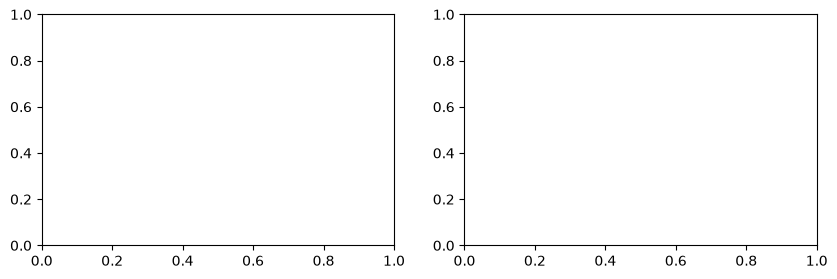

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(y_diff, lags=30, ax=axes[0])
plot_pacf(y_diff, lags=30, ax=axes[1])
plt.tight_layout()

## [Slide 14] The Hyndman-Khandakar AutoARIMA Algorithm

In [5]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import ARIMASummary

sf = StatsForecast(
    models=[AutoARIMA(season_length=12, stepwise=False)],
    freq="MS",
)
sf.fit(df=train)
arima_model = sf.fitted_[0, 0]
print(ARIMASummary(arima_model.model_))

NameError: name 'train' is not defined

## [Slide 18] Ljung-Box Test and Residual Checks

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast.arima import ARIMASummary

residuals = arima_model.model_["residuals"]
K = p + q   # number of AR + MA parameters

lb_result = acorr_ljungbox(residuals, lags=[10], model_df=K)
print(lb_result)
# p > 0.05: residuals consistent with white noise

NameError: name 'arima_model' is not defined

## [Slide 23] Empirical Comparison: Australian Population

In [7]:
from statsforecast.models import AutoARIMA, AutoETS
from utilsforecast.losses import rmse, mae

sf = StatsForecast(
    models=[AutoARIMA(season_length=4), AutoETS(season_length=4)],
    freq="Q",
)
cv = sf.cross_validation(df=train, h=4, n_windows=10)
evaluate(cv.drop("cutoff", axis=1), metrics=[rmse, mae], train_df=train)

NameError: name 'train' is not defined